# Import Qiskit e Librerie Necessarie
Importazione delle librerie Qiskit necessarie per l'implementazione del circuito quantistico e la visualizzazione dei risultati.

In [1]:
# Import Qiskit and necessary libraries
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

from qiskit.circuit.library import UnitaryGate
import numpy as np

from qiskit import transpile
from qiskit_aer import AerSimulator

# Definizione del Circuito di Fase Controllata CR_phi
Implementazione del gate di fase controllata CR_phi che sarà utilizzato come operatore unitario U nell'algoritmo di stima della fase.

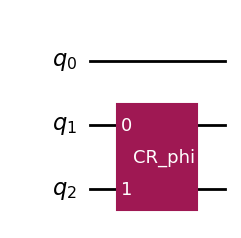

In [2]:
# Definizione del Circuito di Fase Controllata CR_phi


# Funzione per creare il gate di fase controllata CR_phi
def controlled_phase_gate(phi):
    # Matrice unitaria per il gate di fase controllata CR_phi
    cr_phi_matrix = np.array([[1, 0, 0, 0],
                              [0, 1, 0, 0],
                              [0, 0, 1, 0],
                              [0, 0, 0, np.exp(1j * phi)]])
    return UnitaryGate(cr_phi_matrix, label="CR_phi")

# Parametro di fase
phi = np.pi / 8  # esempio di fase

# Creazione del circuito quantistico
qc = QuantumCircuit(3)

# Aggiunta del gate di fase controllata CR_phi
cr_phi = controlled_phase_gate(phi)
qc.append(cr_phi, [1, 2])

# Visualizzazione del circuito
qc.draw('mpl')

# Implementazione del Circuito QFT
Creazione della funzione per implementare la Quantum Fourier Transform (QFT) e la sua inversa, componenti essenziali dell'algoritmo.

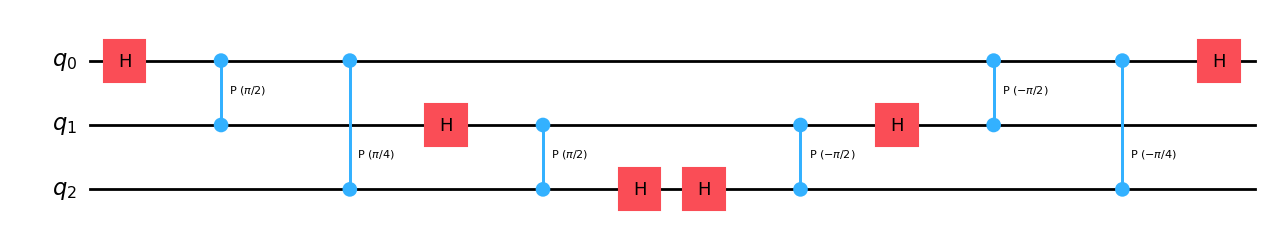

In [3]:
# Implementazione del Circuito QFT

# Funzione per implementare la Quantum Fourier Transform (QFT)
def qft(circuit, n):
    for i in range(n):
        circuit.h(i)
        for j in range(i+1, n):
            circuit.cp(np.pi/2**(j-i), j, i)

# Funzione per implementare l'inversa della Quantum Fourier Transform (QFT)
def inverse_qft(circuit, n):
    for i in range(n-1, -1, -1):
        for j in range(i+1, n):
            circuit.cp(-np.pi/2**(j-i), j, i)
        circuit.h(i)

# Esempio di utilizzo delle funzioni QFT e inverse QFT
n = 3  # numero di qubit
qc = QuantumCircuit(n)

# Applicazione della QFT
qft(qc, n)

# Applicazione dell'inversa della QFT
inverse_qft(qc, n)

# Visualizzazione del circuito
qc.draw('mpl')

# Costruzione del Circuito di Stima della Fase
Assemblaggio del circuito completo per la stima della fase, combinando il registro di precisione, il gate CR_phi e la QFT inversa.

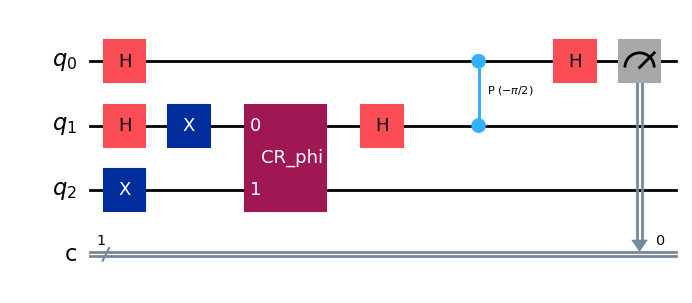

In [4]:
# Costruzione del Circuito di Stima della Fase

# Creazione del circuito quantistico per la stima della fase
qc = QuantumCircuit(3, 1)  # 3 qubit, 1 bit classico

# Registro di precisione: applicazione delle Hadamard
qc.h(0)
qc.h(1)

# Stato iniziale |11>
qc.x(2)
qc.x(1)

# Aggiunta del gate di fase controllata CR_phi
qc.append(cr_phi, [1, 2])

# Applicazione della QFT inversa
inverse_qft(qc, 2)

# Misurazione
qc.measure(0, 0)

# Visualizzazione del circuito
qc.draw('mpl')

# Test con Eigenvettore |11>
Preparazione dello stato eigenvettore |11> e verifica del suo comportamento con il gate CR_phi.

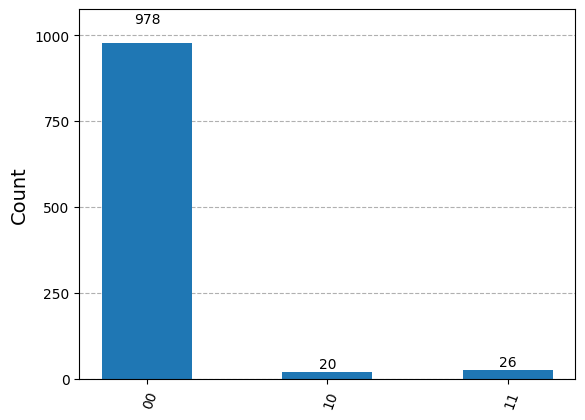

In [5]:
# Test con Eigenvettore |11>

# Preparazione dello stato eigenvettore |11>
qc = QuantumCircuit(3, 2)  # 3 qubit, 2 bit classici

# Registro di precisione: applicazione delle Hadamard
qc.h(0)
qc.h(1)

# Stato iniziale |11>
qc.x(2)
qc.x(1)

# Aggiunta del gate di fase controllata CR_phi
qc.append(cr_phi, [1, 2])

# Applicazione della QFT inversa
inverse_qft(qc, 2)

# Misurazione
qc.measure([0, 1], [0, 1])

# Esecuzione del circuito su un simulatore
simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)
result = simulator.run(transpiled_qc).result()
counts = result.get_counts()

# Visualizzazione dei risultati
plot_histogram(counts)

# Misurazione e Analisi dei Risultati
Esecuzione del circuito, raccolta delle misurazioni e analisi della fase stimata confrontandola con il valore teorico atteso.

In [6]:
# Misurazione e Analisi dei Risultati

# Esecuzione del circuito su un simulatore
simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)
result = simulator.run(transpiled_qc).result()
counts = result.get_counts()

# Visualizzazione dei risultati
plot_histogram(counts)

# Analisi della fase stimata
# Estrazione del risultato più frequente
most_frequent_result = max(counts, key=counts.get)

# Conversione del risultato binario in decimale
estimated_phase_decimal = int(most_frequent_result, 2) / (2**2)  # 2 qubit di precisione

# Calcolo della fase teorica attesa
expected_phase = phi / (2 * np.pi)

# Stampa dei risultati
print(f"Fase stimata: {estimated_phase_decimal}")
print(f"Fase teorica attesa: {expected_phase}")

Fase stimata: 0.0
Fase teorica attesa: 0.0625
